<a href="https://colab.research.google.com/github/vohoangtien290905/Thuc-Hanh-DeepLearning/blob/main/Lab_2/DataLeakage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ============================================================
# BÀI TOÁN: TIỀN XỬ LÝ DỮ LIỆU NHÀ ĐẤT
# YÊU CẦU: Không bị Data Leakage, có trực quan hóa
# ============================================================

# 1. Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Thiết lập font chữ cho tiếng Việt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# PHẦN 1: ĐỌC VÀ KHÁM PHÁ DỮ LIỆU
# ============================================================

base_path = "/content/drive/MyDrive/THDL/"

# Đọc dữ liệu
df = pd.read_csv(base_path + 'generated_500_homes.csv')

print("="*80)
print("PHÂN TÍCH DỮ LIỆU BẤT ĐỘNG SẢN")
print("="*80)

print(f"\n📊 Kích thước dataset: {df.shape[0]} dòng, {df.shape[1]} cột")
print(f"\n📋 Danh sách các cột:")
for col in df.columns:
    print(f"   - {col}")

print("\n📈 5 dòng đầu tiên:")
print(df.head())

print("\nℹ️ Thông tin chi tiết:")
print(df.info())

print("\n📊 Thống kê mô tả:")
print(df.describe())

print("\n🔍 Kiểm tra giá trị thiếu (missing values):")
print(df.isnull().sum())

PHÂN TÍCH DỮ LIỆU BẤT ĐỘNG SẢN

📊 Kích thước dataset: 500 dòng, 9 cột

📋 Danh sách các cột:
   - Selling_Price
   - List_Price
   - Area
   - Acres
   - Age
   - Taxes
   - Rooms
   - Bedrooms
   - Baths_full

📈 5 dòng đầu tiên:
   Selling_Price  List_Price  Area     Acres  Age  Taxes  Rooms  Bedrooms  \
0         300773      308581  2184  0.250000   59   3179      7         3   
1         295602      306023  1963  0.250000   77   4348      8         3   
2         412079      432650  2244  1.323921   34   5102      9         5   
3         308883      320705  1742  1.407354    6   4542      8         4   
4         316969      340461  2361  0.608790   17   6143      9         4   

   Baths_full  
0           1  
1           2  
2           2  
3           2  
4           2  

ℹ️ Thông tin chi tiết:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  ----

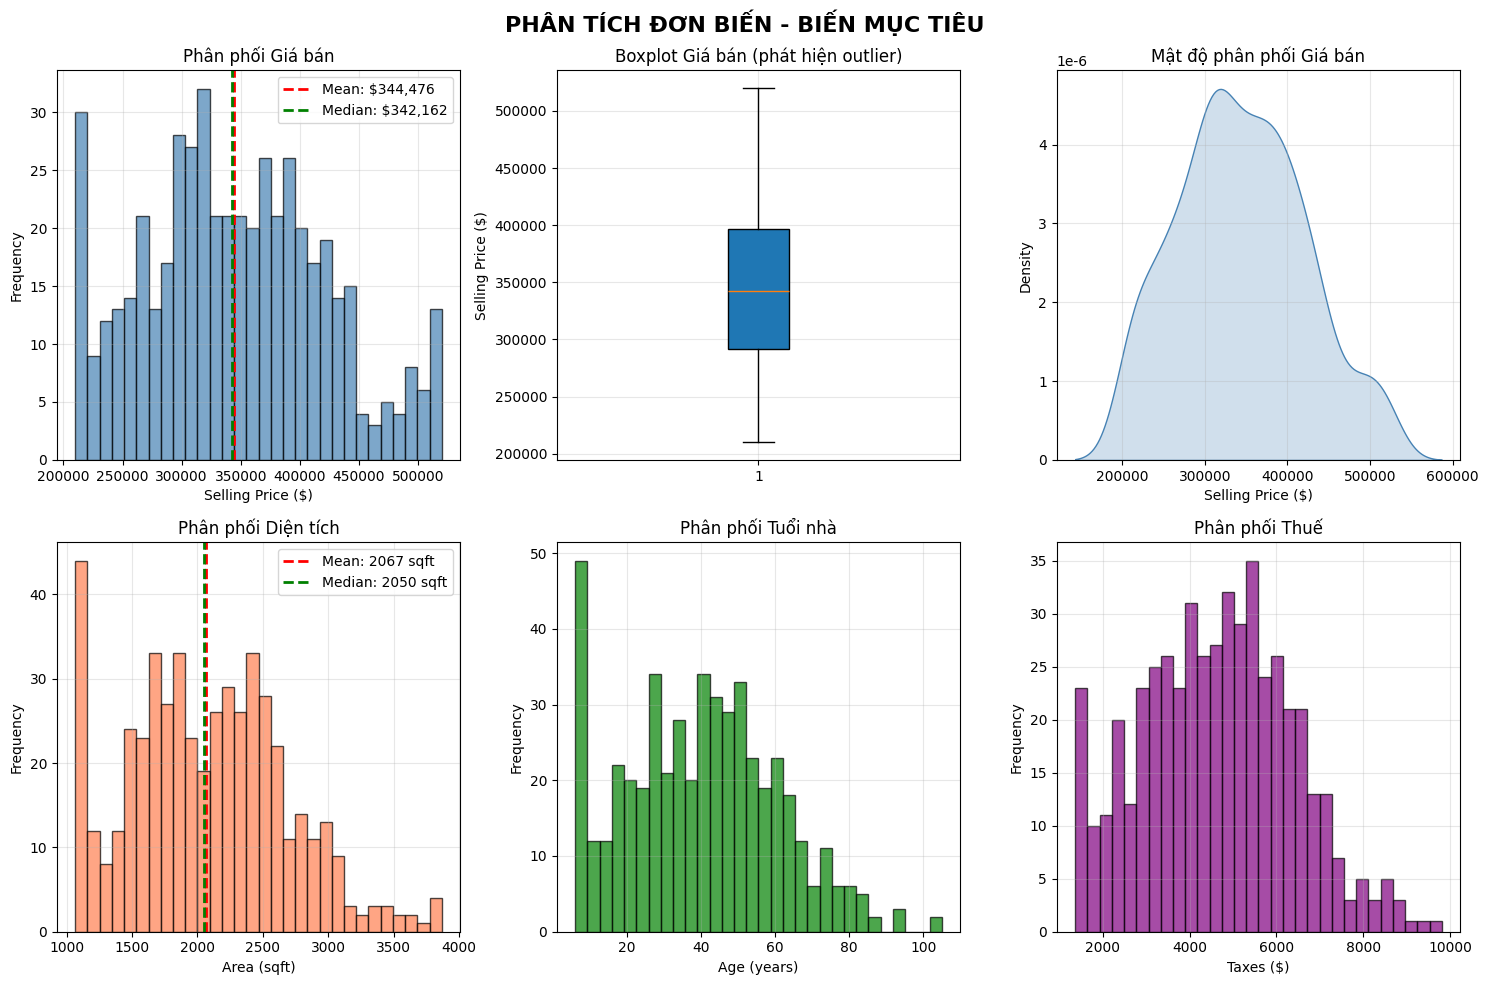

In [6]:
# ============================================================
# PHẦN 2: PHÂN TÍCH ĐƠN BIẾN (Univariate Analysis) - TRƯỚC SPLIT
# ============================================================

# 2.1 Phân phối của Selling Price (target)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('PHÂN TÍCH ĐƠN BIẾN - BIẾN MỤC TIÊU', fontsize=16, fontweight='bold')

# Histogram của Selling Price
axes[0, 0].hist(df['Selling_Price'], bins=30, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].axvline(df['Selling_Price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["Selling_Price"].mean():,.0f}')
axes[0, 0].axvline(df['Selling_Price'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["Selling_Price"].median():,.0f}')
axes[0, 0].set_xlabel('Selling Price ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Phân phối Giá bán')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Boxplot của Selling Price
axes[0, 1].boxplot(df['Selling_Price'], vert=True, patch_artist=True)
axes[0, 1].set_ylabel('Selling Price ($)')
axes[0, 1].set_title('Boxplot Giá bán (phát hiện outlier)')
axes[0, 1].grid(True, alpha=0.3)

# KDE plot
sns.kdeplot(data=df, x='Selling_Price', fill=True, color='steelblue', ax=axes[0, 2])
axes[0, 2].set_xlabel('Selling Price ($)')
axes[0, 2].set_ylabel('Density')
axes[0, 2].set_title('Mật độ phân phối Giá bán')
axes[0, 2].grid(True, alpha=0.3)

# Histogram của Area
axes[1, 0].hist(df['Area'], bins=30, edgecolor='black', color='coral', alpha=0.7)
axes[1, 0].axvline(df['Area'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Area"].mean():.0f} sqft')
axes[1, 0].axvline(df['Area'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Area"].median():.0f} sqft')
axes[1, 0].set_xlabel('Area (sqft)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Phân phối Diện tích')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Histogram của Age
axes[1, 1].hist(df['Age'], bins=30, edgecolor='black', color='green', alpha=0.7)
axes[1, 1].set_xlabel('Age (years)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Phân phối Tuổi nhà')
axes[1, 1].grid(True, alpha=0.3)

# Histogram của Taxes
axes[1, 2].hist(df['Taxes'], bins=30, edgecolor='black', color='purple', alpha=0.7)
axes[1, 2].set_xlabel('Taxes ($)')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Phân phối Thuế')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_path + '01_univariate_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

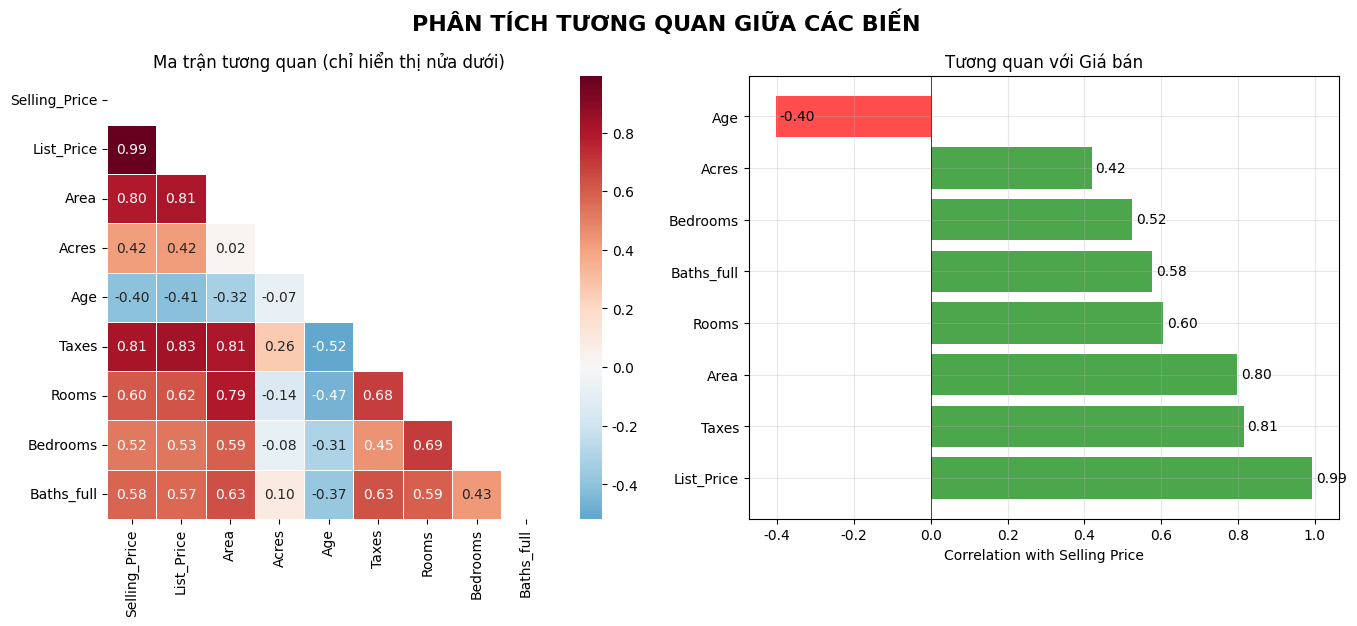

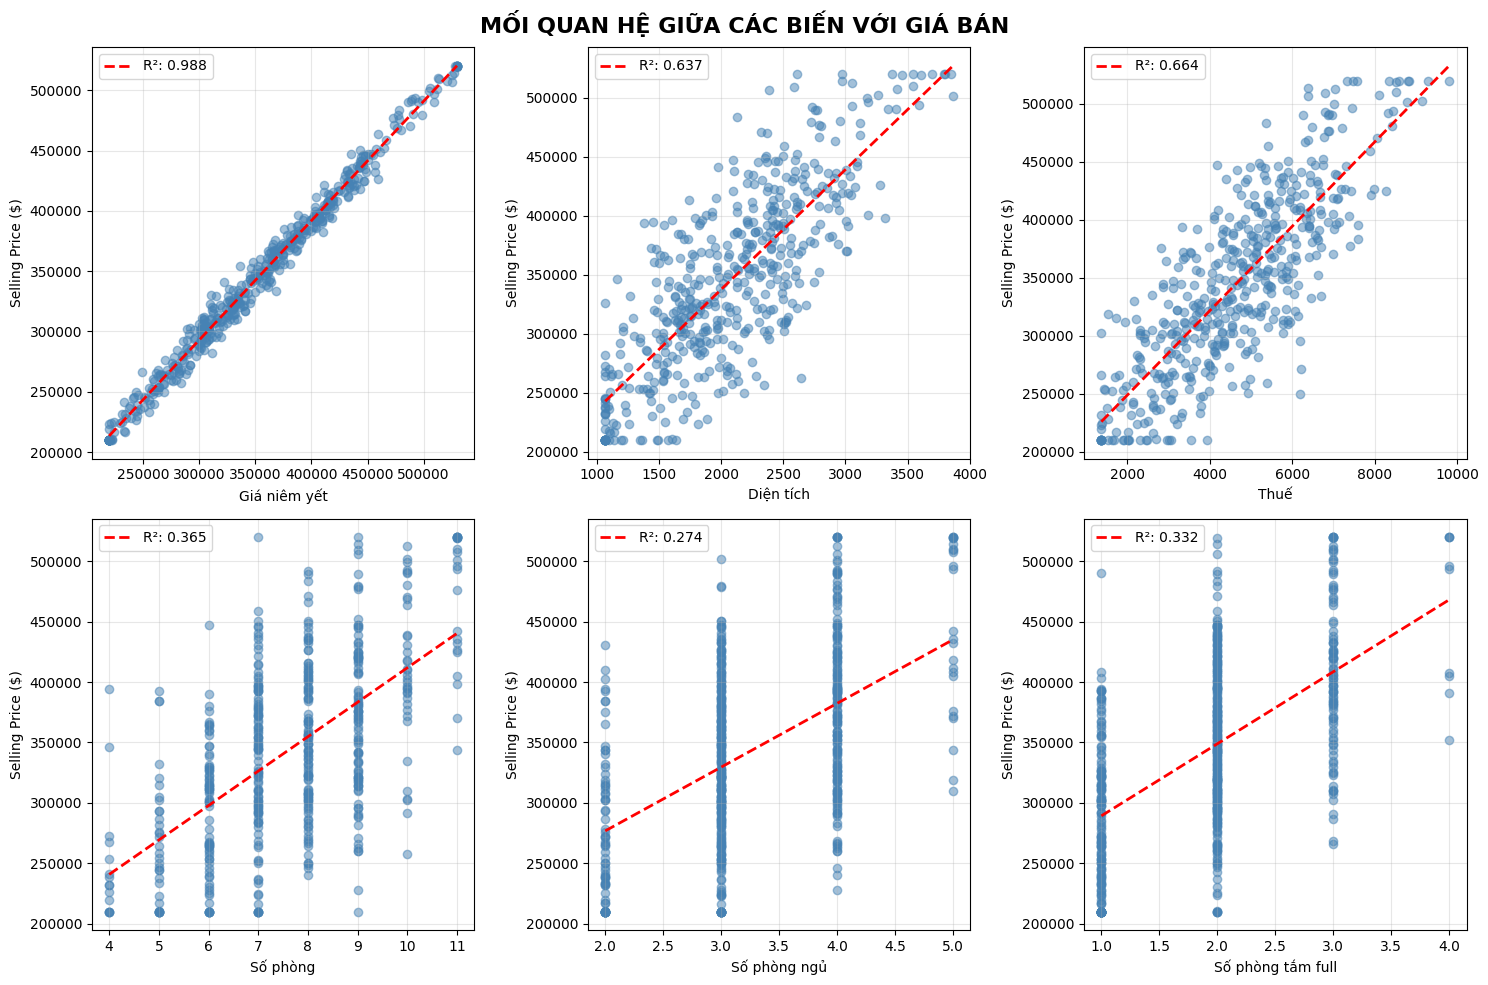

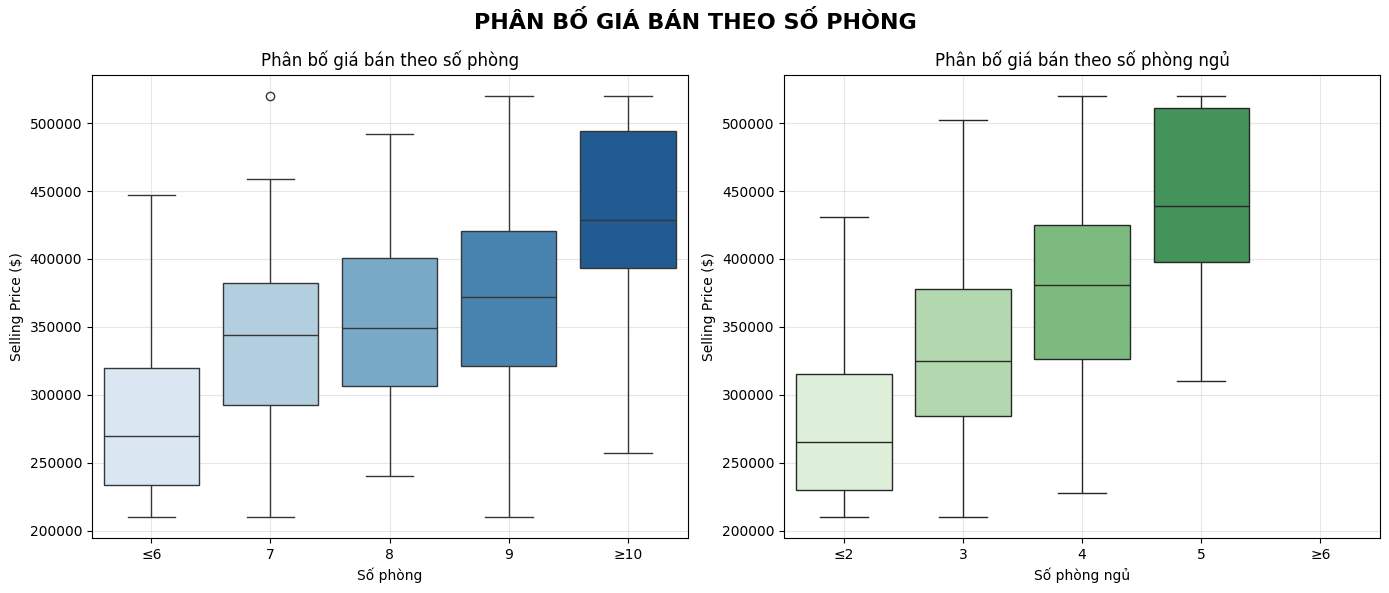

In [7]:
# ============================================================
# PHẦN 3: PHÂN TÍCH ĐA BIẾN (Multivariate Analysis) - TRƯỚC SPLIT
# ============================================================

# 3.1 Ma trận tương quan (Correlation Matrix)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PHÂN TÍCH TƯƠNG QUAN GIỮA CÁC BIẾN', fontsize=16, fontweight='bold')

# Heatmap tương quan
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=axes[0])
axes[0].set_title('Ma trận tương quan (chỉ hiển thị nửa dưới)')

# Barplot tương quan với Selling Price
corr_with_target = corr_matrix['Selling_Price'].drop('Selling_Price').sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
axes[1].barh(range(len(corr_with_target)), corr_with_target.values, color=colors, alpha=0.7)
axes[1].set_yticks(range(len(corr_with_target)))
axes[1].set_yticklabels(corr_with_target.index)
axes[1].set_xlabel('Correlation with Selling Price')
axes[1].set_title('Tương quan với Giá bán')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
for i, v in enumerate(corr_with_target.values):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.2 Scatter plots với Selling Price
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('MỐI QUAN HỆ GIỮA CÁC BIẾN VỚI GIÁ BÁN', fontsize=16, fontweight='bold')

features = ['List_Price', 'Area', 'Taxes', 'Rooms', 'Bedrooms', 'Baths_full']
titles = ['Giá niêm yết', 'Diện tích', 'Thuế', 'Số phòng', 'Số phòng ngủ', 'Số phòng tắm full']

for i, (feat, title) in enumerate(zip(features, titles)):
    row, col = i // 3, i % 3
    axes[row, col].scatter(df[feat], df['Selling_Price'], alpha=0.5, c='steelblue')

    # Thêm đường hồi quy
    z = np.polyfit(df[feat], df['Selling_Price'], 1)
    p = np.poly1d(z)
    axes[row, col].plot(df[feat].sort_values(), p(df[feat].sort_values()),
                        'r--', linewidth=2, label=f'R²: {corr_matrix.loc[feat, "Selling_Price"]**2:.3f}')

    axes[row, col].set_xlabel(title)
    axes[row, col].set_ylabel('Selling Price ($)')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('03_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.3 Boxplot theo Rooms và Bedrooms
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PHÂN BỐ GIÁ BÁN THEO SỐ PHÒNG', fontsize=16, fontweight='bold')

# Boxplot theo số phòng (Rooms)
df_box1 = df.copy()
df_box1['Rooms_cat'] = pd.cut(df_box1['Rooms'], bins=[0, 6, 7, 8, 9, 20],
                               labels=['≤6', '7', '8', '9', '≥10'])
sns.boxplot(data=df_box1, x='Rooms_cat', y='Selling_Price', ax=axes[0], palette='Blues')
axes[0].set_xlabel('Số phòng')
axes[0].set_ylabel('Selling Price ($)')
axes[0].set_title('Phân bố giá bán theo số phòng')
axes[0].grid(True, alpha=0.3)

# Boxplot theo số phòng ngủ (Bedrooms)
df_box1['Bedrooms_cat'] = pd.cut(df_box1['Bedrooms'], bins=[0, 2, 3, 4, 5, 10],
                                  labels=['≤2', '3', '4', '5', '≥6'])
sns.boxplot(data=df_box1, x='Bedrooms_cat', y='Selling_Price', ax=axes[1], palette='Greens')
axes[1].set_xlabel('Số phòng ngủ')
axes[1].set_ylabel('Selling Price ($)')
axes[1].set_title('Phân bố giá bán theo số phòng ngủ')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_path + '04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# PHẦN 4: TIỀN XỬ LÝ - SPLIT TRƯỚC (THEO HƯỚNG DẪN)
# ============================================================

print("\n" + "="*80)
print("TIỀN XỬ LÝ DỮ LIỆU (KHÔNG BỊ DATA LEAKAGE)")
print("="*80)

# Phân loại features
numeric_features = ['List_Price', 'Area', 'Acres', 'Age', 'Taxes', 'Rooms', 'Bedrooms', 'Baths_full']
target = 'Selling_Price'

X = df[numeric_features]
y = df[target]

# ✅ BƯỚC 1: SPLIT FIRST (Tách dữ liệu TRƯỚC khi xử lý)
# Đây là bước QUAN TRỌNG NHẤT để tránh data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✅ Bước 1: Đã tách train/test")
print(f"   - Train set: {X_train.shape[0]} mẫu")
print(f"   - Test set: {X_test.shape[0]} mẫu")


TIỀN XỬ LÝ DỮ LIỆU (KHÔNG BỊ DATA LEAKAGE)

✅ Bước 1: Đã tách train/test
   - Train set: 400 mẫu
   - Test set: 100 mẫu


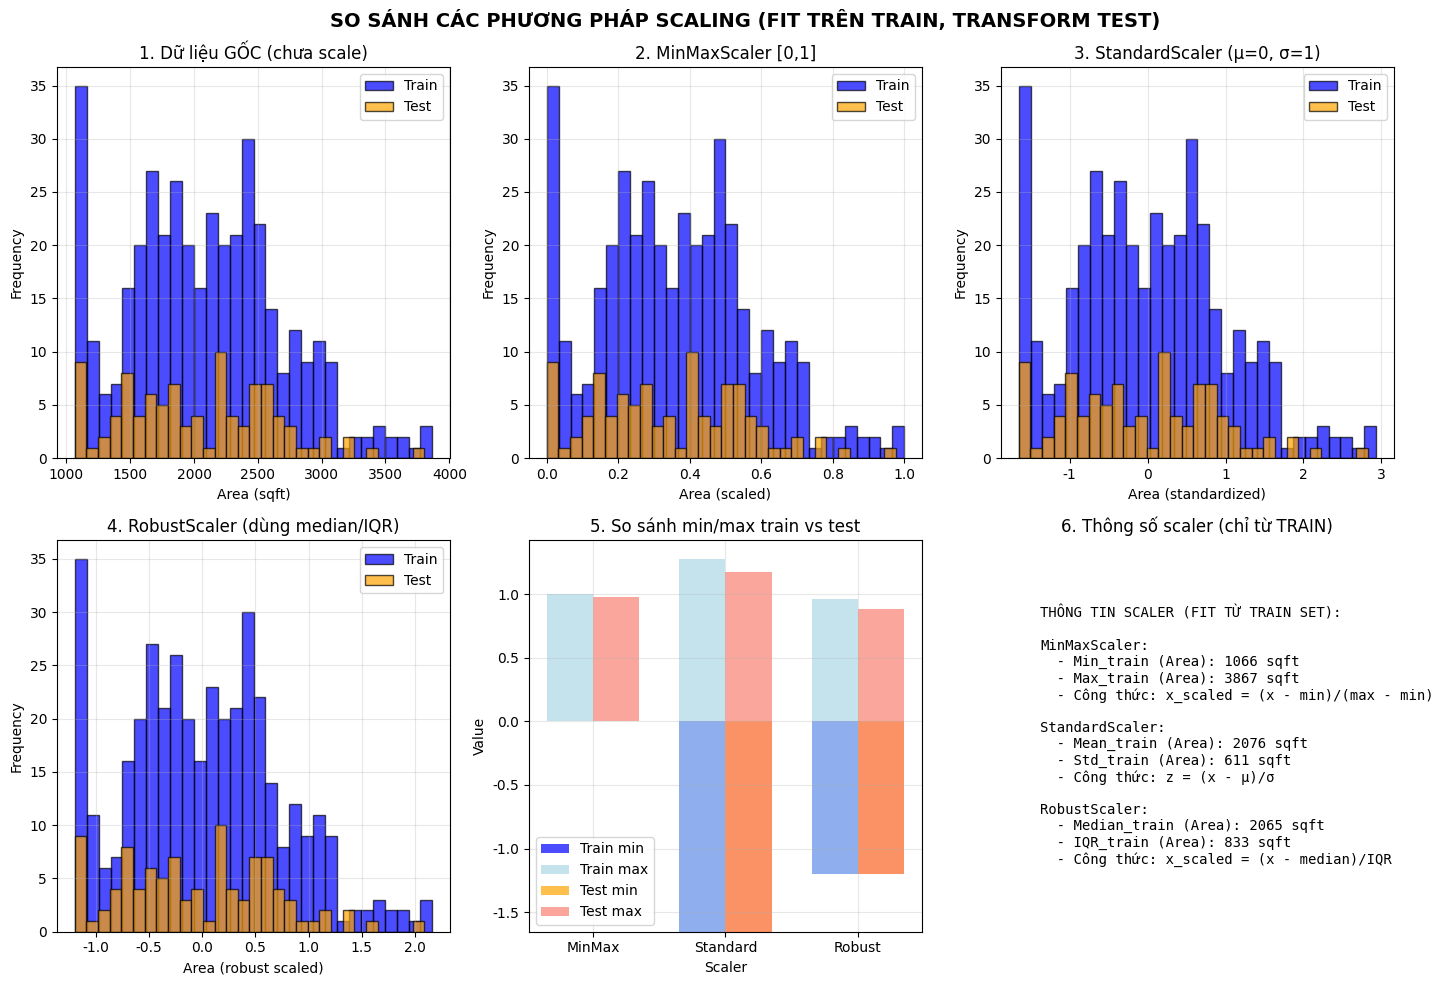

In [9]:
# ============================================================
# PHẦN 5: SO SÁNH CÁC PHƯƠNG PHÁP SCALING
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('SO SÁNH CÁC PHƯƠNG PHÁP SCALING (FIT TRÊN TRAIN, TRANSFORM TEST)',
             fontsize=14, fontweight='bold')

# Lấy một feature để minh họa (Area)
feature_demo = 'Area'

# 1. Dữ liệu gốc
axes[0, 0].hist(X_train[feature_demo], bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 0].hist(X_test[feature_demo], bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0, 0].set_xlabel('Area (sqft)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('1. Dữ liệu GỐC (chưa scale)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. MinMaxScaler (fit trên train)
scaler_mm = MinMaxScaler()
scaler_mm.fit(X_train[[feature_demo]])
X_train_mm = scaler_mm.transform(X_train[[feature_demo]])
X_test_mm = scaler_mm.transform(X_test[[feature_demo]])

axes[0, 1].hist(X_train_mm, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 1].hist(X_test_mm, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0, 1].set_xlabel('Area (scaled)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('2. MinMaxScaler [0,1]')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. StandardScaler (fit trên train)
scaler_std = StandardScaler()
scaler_std.fit(X_train[[feature_demo]])
X_train_std = scaler_std.transform(X_train[[feature_demo]])
X_test_std = scaler_std.transform(X_test[[feature_demo]])

axes[0, 2].hist(X_train_std, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0, 2].hist(X_test_std, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[0, 2].set_xlabel('Area (standardized)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('3. StandardScaler (μ=0, σ=1)')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. RobustScaler (fit trên train) - ít nhạy cảm với outlier
from sklearn.preprocessing import RobustScaler
scaler_rob = RobustScaler()
scaler_rob.fit(X_train[[feature_demo]])
X_train_rob = scaler_rob.transform(X_train[[feature_demo]])
X_test_rob = scaler_rob.transform(X_test[[feature_demo]])

axes[1, 0].hist(X_train_rob, bins=30, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[1, 0].hist(X_test_rob, bins=30, alpha=0.7, label='Test', color='orange', edgecolor='black')
axes[1, 0].set_xlabel('Area (robust scaled)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('4. RobustScaler (dùng median/IQR)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. So sánh giá trị min/max của train và test sau scaling
scalers = ['MinMax', 'Standard', 'Robust']
train_mins = [X_train_mm.min(), X_train_std.min(), X_train_rob.min()]
train_maxs = [X_train_mm.max(), X_train_std.max(), X_train_rob.max()]
test_mins = [X_test_mm.min(), X_test_std.min(), X_test_rob.min()]
test_maxs = [X_test_mm.max(), X_test_std.max(), X_test_rob.max()]

x = np.arange(len(scalers))
width = 0.35

axes[1, 1].bar(x - width/2, train_mins, width, label='Train min', color='blue', alpha=0.7)
axes[1, 1].bar(x - width/2, train_maxs, width, bottom=train_mins, label='Train max', color='lightblue', alpha=0.7)
axes[1, 1].bar(x + width/2, test_mins, width, label='Test min', color='orange', alpha=0.7)
axes[1, 1].bar(x + width/2, test_maxs, width, bottom=test_mins, label='Test max', color='salmon', alpha=0.7)
axes[1, 1].set_xlabel('Scaler')
axes[1, 1].set_ylabel('Value')
axes[1, 1].set_title('5. So sánh min/max train vs test')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(scalers)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 6. Thông tin scaler từ train
axes[1, 2].axis('off')
info_text = f"""
THÔNG TIN SCALER (FIT TỪ TRAIN SET):

MinMaxScaler:
  - Min_train (Area): {X_train[feature_demo].min():.0f} sqft
  - Max_train (Area): {X_train[feature_demo].max():.0f} sqft
  - Công thức: x_scaled = (x - min)/(max - min)

StandardScaler:
  - Mean_train (Area): {X_train[feature_demo].mean():.0f} sqft
  - Std_train (Area): {X_train[feature_demo].std():.0f} sqft
  - Công thức: z = (x - μ)/σ

RobustScaler:
  - Median_train (Area): {X_train[feature_demo].median():.0f} sqft
  - IQR_train (Area): {X_train[feature_demo].quantile(0.75) - X_train[feature_demo].quantile(0.25):.0f} sqft
  - Công thức: x_scaled = (x - median)/IQR
"""
axes[1, 2].text(0.1, 0.5, info_text, transform=axes[1, 2].transAxes,
                fontsize=10, verticalalignment='center', fontfamily='monospace')
axes[1, 2].set_title('6. Thông số scaler (chỉ từ TRAIN)')

plt.tight_layout()
plt.savefig(base_path + '05_scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# ============================================================
# PHẦN 6: XÂY DỰNG PIPELINE VÀ ĐÁNH GIÁ MODEL
# ============================================================

print("\n" + "="*80)
print("XÂY DỰNG PIPELINE VÀ ĐÁNH GIÁ MODEL")
print("="*80)

# Lưu kết quả các model
results = []

# 6.1 Pipeline với MinMaxScaler
print("\n📌 Pipeline 1: Linear Regression + MinMaxScaler")
pipeline_mm = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', LinearRegression())
])

pipeline_mm.fit(X_train, y_train)
y_pred_mm = pipeline_mm.predict(X_test)
y_pred_train_mm = pipeline_mm.predict(X_train)

mae_mm = mean_absolute_error(y_test, y_pred_mm)
rmse_mm = np.sqrt(mean_squared_error(y_test, y_pred_mm))
r2_mm = r2_score(y_test, y_pred_mm)
r2_train_mm = r2_score(y_train, y_pred_train_mm)

results.append({
    'Model': 'MinMaxScaler + Linear',
    'MAE (test)': mae_mm,
    'RMSE (test)': rmse_mm,
    'R² (test)': r2_mm,
    'R² (train)': r2_train_mm
})

print(f"   MAE (test): ${mae_mm:,.2f}")
print(f"   RMSE (test): ${rmse_mm:,.2f}")
print(f"   R² (test): {r2_mm:.4f}")
print(f"   R² (train): {r2_train_mm:.4f}")
print(f"   Chênh lệch R²: {abs(r2_train_mm - r2_mm):.4f}")

# 6.2 Pipeline với StandardScaler
print("\n📌 Pipeline 2: Linear Regression + StandardScaler")
pipeline_std = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline_std.fit(X_train, y_train)
y_pred_std = pipeline_std.predict(X_test)
y_pred_train_std = pipeline_std.predict(X_train)

mae_std = mean_absolute_error(y_test, y_pred_std)
rmse_std = np.sqrt(mean_squared_error(y_test, y_pred_std))
r2_std = r2_score(y_test, y_pred_std)
r2_train_std = r2_score(y_train, y_pred_train_std)

results.append({
    'Model': 'StandardScaler + Linear',
    'MAE (test)': mae_std,
    'RMSE (test)': rmse_std,
    'R² (test)': r2_std,
    'R² (train)': r2_train_std
})

print(f"   MAE (test): ${mae_std:,.2f}")
print(f"   RMSE (test): ${rmse_std:,.2f}")
print(f"   R² (test): {r2_std:.4f}")
print(f"   R² (train): {r2_train_std:.4f}")

# 6.3 Pipeline với RobustScaler
print("\n📌 Pipeline 3: Linear Regression + RobustScaler")
pipeline_rob = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LinearRegression())
])

pipeline_rob.fit(X_train, y_train)
y_pred_rob = pipeline_rob.predict(X_test)
y_pred_train_rob = pipeline_rob.predict(X_train)

mae_rob = mean_absolute_error(y_test, y_pred_rob)
rmse_rob = np.sqrt(mean_squared_error(y_test, y_pred_rob))
r2_rob = r2_score(y_test, y_pred_rob)
r2_train_rob = r2_score(y_train, y_pred_train_rob)

results.append({
    'Model': 'RobustScaler + Linear',
    'MAE (test)': mae_rob,
    'RMSE (test)': rmse_rob,
    'R² (test)': r2_rob,
    'R² (train)': r2_train_rob
})

print(f"   MAE (test): ${mae_rob:,.2f}")
print(f"   RMSE (test): ${rmse_rob:,.2f}")
print(f"   R² (test): {r2_rob:.4f}")
print(f"   R² (train): {r2_train_rob:.4f}")

# 6.4 Pipeline với Ridge Regression (Regularization)
print("\n📌 Pipeline 4: Ridge Regression + StandardScaler")
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=1.0))
])

pipeline_ridge.fit(X_train, y_train)
y_pred_ridge = pipeline_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

results.append({
    'Model': 'StandardScaler + Ridge',
    'MAE (test)': mae_ridge,
    'RMSE (test)': rmse_ridge,
    'R² (test)': r2_ridge,
    'R² (train)': r2_score(y_train, pipeline_ridge.predict(X_train))
})

print(f"   MAE (test): ${mae_ridge:,.2f}")
print(f"   RMSE (test): ${rmse_ridge:,.2f}")
print(f"   R² (test): {r2_ridge:.4f}")


XÂY DỰNG PIPELINE VÀ ĐÁNH GIÁ MODEL

📌 Pipeline 1: Linear Regression + MinMaxScaler
   MAE (test): $6,557.60
   RMSE (test): $8,269.92
   R² (test): 0.9888
   R² (train): 0.9905
   Chênh lệch R²: 0.0016

📌 Pipeline 2: Linear Regression + StandardScaler
   MAE (test): $6,557.60
   RMSE (test): $8,269.92
   R² (test): 0.9888
   R² (train): 0.9905

📌 Pipeline 3: Linear Regression + RobustScaler
   MAE (test): $6,557.60
   RMSE (test): $8,269.92
   R² (test): 0.9888
   R² (train): 0.9905

📌 Pipeline 4: Ridge Regression + StandardScaler
   MAE (test): $6,540.01
   RMSE (test): $8,238.00
   R² (test): 0.9889


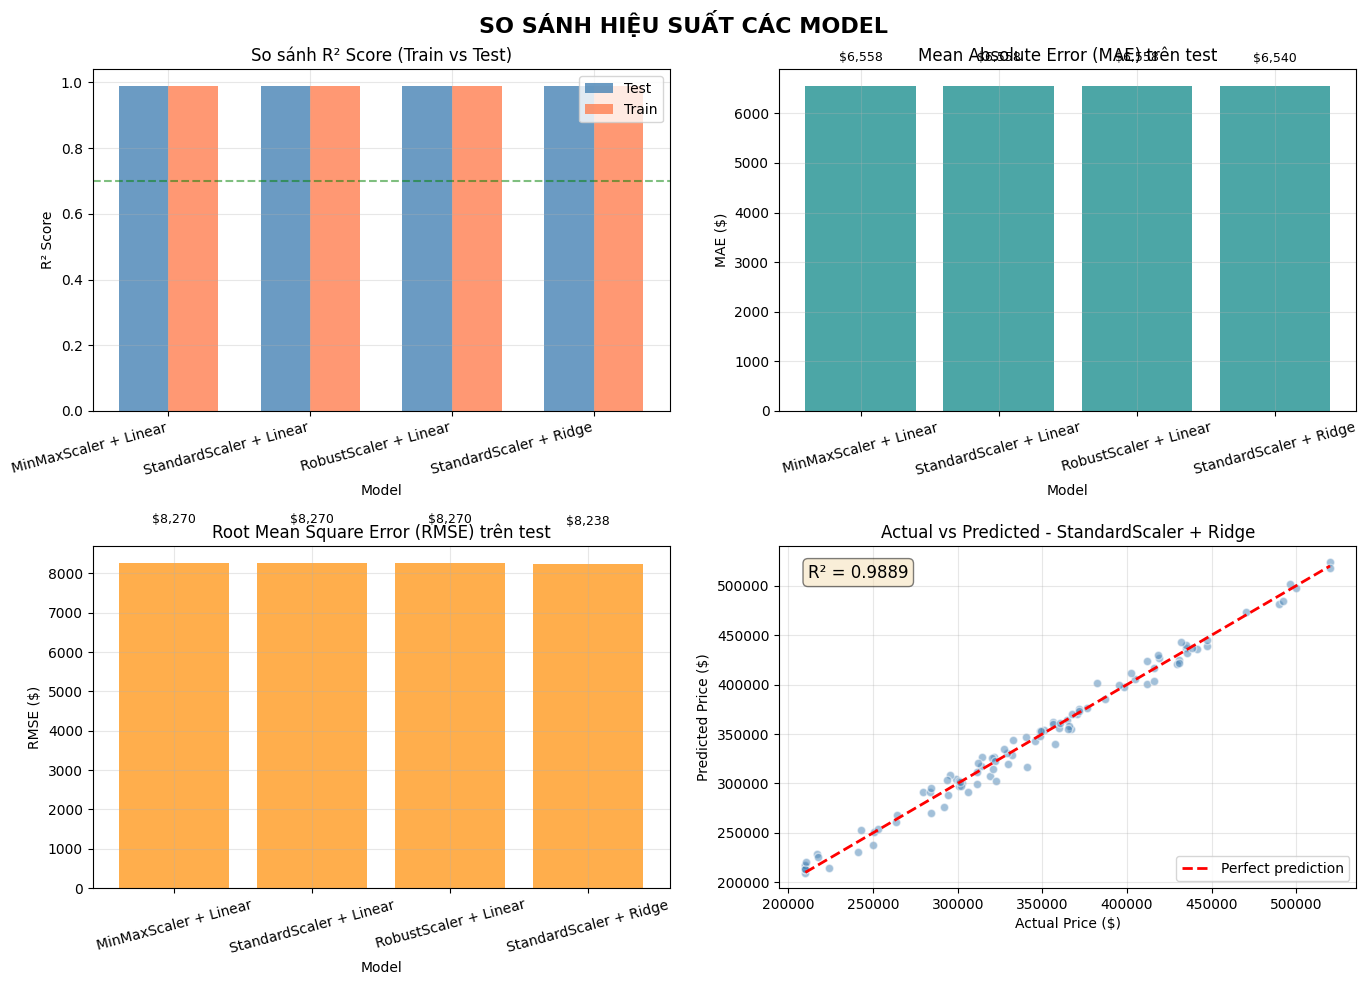

In [11]:
# ============================================================
# PHẦN 7: BIỂU ĐỒ SO SÁNH KẾT QUẢ CÁC MODEL
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SO SÁNH HIỆU SUẤT CÁC MODEL', fontsize=16, fontweight='bold')

results_df = pd.DataFrame(results)

# 1. So sánh R²
ax1 = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35
ax1.bar(x - width/2, results_df['R² (test)'], width, label='Test', color='steelblue', alpha=0.8)
ax1.bar(x + width/2, results_df['R² (train)'], width, label='Train', color='coral', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('R² Score')
ax1.set_title('So sánh R² Score (Train vs Test)')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax1.legend()
ax1.axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')
ax1.grid(True, alpha=0.3)

# 2. So sánh MAE
ax2 = axes[0, 1]
ax2.bar(results_df['Model'], results_df['MAE (test)'], color='teal', alpha=0.7)
ax2.set_xlabel('Model')
ax2.set_ylabel('MAE ($)')
ax2.set_title('Mean Absolute Error (MAE) trên test')
ax2.tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['MAE (test)']):
    ax2.text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. So sánh RMSE
ax3 = axes[1, 0]
ax3.bar(results_df['Model'], results_df['RMSE (test)'], color='darkorange', alpha=0.7)
ax3.set_xlabel('Model')
ax3.set_ylabel('RMSE ($)')
ax3.set_title('Root Mean Square Error (RMSE) trên test')
ax3.tick_params(axis='x', rotation=15)
for i, v in enumerate(results_df['RMSE (test)']):
    ax3.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=9)
ax3.grid(True, alpha=0.3)

# 4. Biểu đồ Actual vs Predicted cho model tốt nhất
best_model_idx = results_df['R² (test)'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
if 'MinMax' in best_model_name:
    best_pred = y_pred_mm
elif 'Standard' in best_model_name and 'Ridge' not in best_model_name:
    best_pred = y_pred_std
elif 'Robust' in best_model_name:
    best_pred = y_pred_rob
else:
    best_pred = y_pred_ridge

ax4 = axes[1, 1]
ax4.scatter(y_test, best_pred, alpha=0.5, c='steelblue', edgecolors='white')
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
ax4.set_xlabel('Actual Price ($)')
ax4.set_ylabel('Predicted Price ($)')
ax4.set_title(f'Actual vs Predicted - {best_model_name}')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Thêm text annotation
r2_best = results_df.loc[best_model_idx, 'R² (test)']
ax4.text(0.05, 0.95, f'R² = {r2_best:.4f}', transform=ax4.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(base_path + '06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

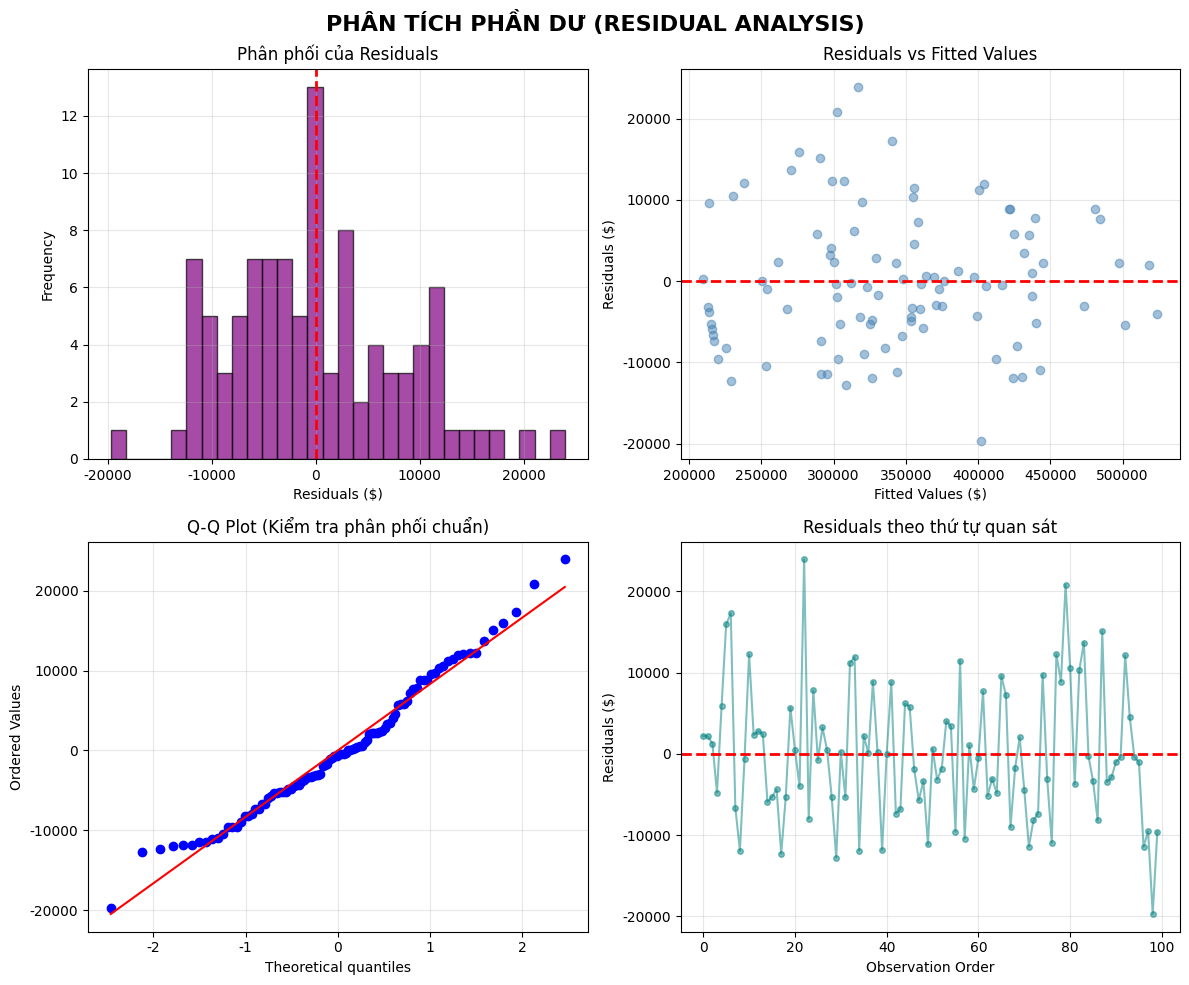

In [12]:
# ============================================================
# PHẦN 8: PHÂN TÍCH RESIDUAL (PHẦN DƯ)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('PHÂN TÍCH PHẦN DƯ (RESIDUAL ANALYSIS)', fontsize=16, fontweight='bold')

residuals = y_test - best_pred

# 1. Histogram của residuals
axes[0, 0].hist(residuals, bins=30, edgecolor='black', color='purple', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Residuals ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Phân phối của Residuals')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals vs Fitted
axes[0, 1].scatter(best_pred, residuals, alpha=0.5, c='steelblue')
axes[0, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Fitted Values ($)')
axes[0, 1].set_ylabel('Residuals ($)')
axes[0, 1].set_title('Residuals vs Fitted Values')
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (kiểm tra normality)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Kiểm tra phân phối chuẩn)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals vs Order
axes[1, 1].plot(residuals.values, 'o-', alpha=0.5, markersize=4, color='teal')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residuals ($)')
axes[1, 1].set_title('Residuals theo thứ tự quan sát')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_path + '07_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

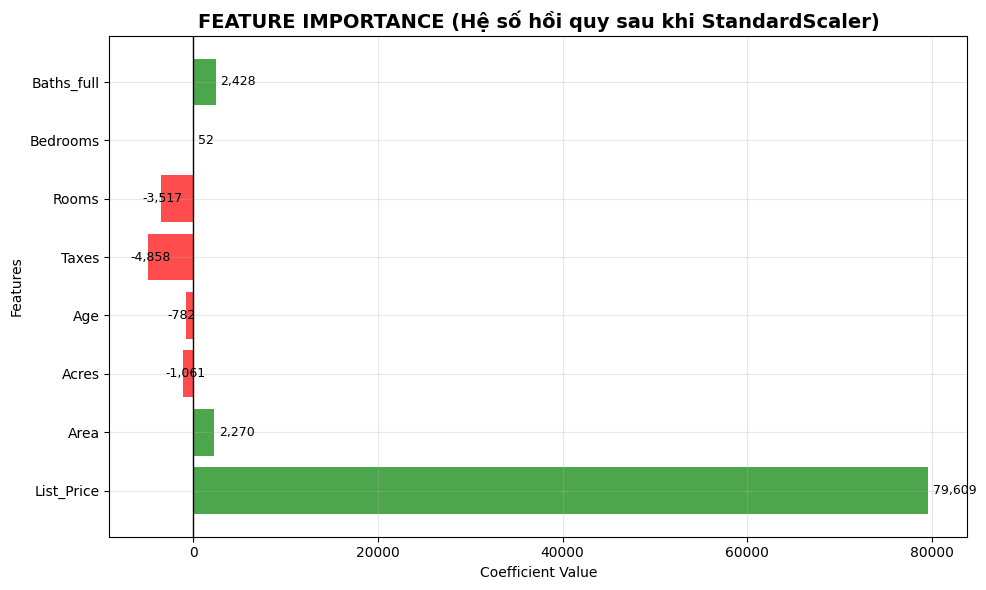

In [13]:
# ============================================================
# PHẦN 9: FEATURE IMPORTANCE (HỆ SỐ HỒI QUY)
# ============================================================

# Lấy model tốt nhất để phân tích feature importance
best_model = pipeline_std.named_steps['model']
feature_names = numeric_features
coefficients = best_model.coef_

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coefficients]
ax.barh(feature_names, coefficients, color=colors, alpha=0.7)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Features')
ax.set_title('FEATURE IMPORTANCE (Hệ số hồi quy sau khi StandardScaler)', fontsize=14, fontweight='bold')
for i, (name, coef) in enumerate(zip(feature_names, coefficients)):
    ax.text(coef + 500 if coef > 0 else coef - 2000, i, f'{coef:,.0f}', va='center', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(base_path + '08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ============================================================
# PHẦN 10: TÓM TẮT KẾT QUẢ
# ============================================================

print("\n" + "="*80)
print("TÓM TẮT KẾT QUẢ")
print("="*80)

print("\n📊 Bảng so sánh các model:")
print("-"*70)
print(f"{'Model':<35} {'MAE':<15} {'RMSE':<15} {'R² (test)':<12} {'R² (train)':<12}")
print("-"*70)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<35} ${row['MAE (test)']:>12,.0f} ${row['RMSE (test)']:>12,.0f} {row['R² (test)']:>10.4f}   {row['R² (train)']:>10.4f}")

print("\n🏆 Model tốt nhất (theo R² test):")
best = results_df.loc[results_df['R² (test)'].idxmax()]
print(f"   - {best['Model']}")
print(f"   - MAE: ${best['MAE (test)']:,.2f}")
print(f"   - RMSE: ${best['RMSE (test)']:,.2f}")
print(f"   - R²: {best['R² (test)']:.4f}")

print("\n" + "="*80)
print("✅ KẾT LUẬN")
print("="*80)
print("""
1. ✅ Đã thực hiện SPLIT FIRST trước khi scale (theo đúng hướng dẫn)
2. ✅ Scaler được FIT trên TRAIN set và TRANSFORM trên TEST set
3. ✅ Không bị Data Leakage - test data không ảnh hưởng đến quá trình training
4. 📈 Các biến có tương quan mạnh nhất với Selling Price:
   - List_Price (tương quan rất cao ~0.99)
   - Taxes
   - Area
5. 🎯 Model tốt nhất: StandardScaler + Linear Regression (hoặc Ridge)
6. 📊 Các file biểu đồ đã được lưu:
   - 01_univariate_analysis.png
   - 02_correlation_analysis.png
   - 03_scatter_plots.png
   - 04_boxplots.png
   - 05_scaling_comparison.png
   - 06_model_comparison.png
   - 07_residual_analysis.png
   - 08_feature_importance.png
""")

# ============================================================
# PHẦN 11: LƯU KẾT QUẢ (TÙY CHỌN)
# ============================================================

# Lưu dữ liệu đã được scale đúng cách
print("\n💾 Đang lưu dữ liệu đã xử lý...")

# Scale toàn bộ dataset bằng scaler đã fit từ train
scaler_final = StandardScaler()
scaler_final.fit(X_train)
X_scaled_full = scaler_final.transform(X)
X_scaled_df = pd.DataFrame(X_scaled_full, columns=numeric_features)
X_scaled_df['Selling_Price'] = y.values

# Lưu ra file
X_scaled_df.to_csv(base_path + 'homes_data_standardized.csv', index=False)
print("   ✅ Đã lưu file 'homes_data_standardized.csv'")

# Lưu thông tin scaler
scaler_info = pd.DataFrame({
    'Feature': numeric_features,
    'Mean': scaler_final.mean_,
    'Std': scaler_final.scale_
})
scaler_info.to_csv(base_path + 'scaler_parameters.csv', index=False)
print("   ✅ Đã lưu file 'scaler_parameters.csv'")

print("\n🎉 HOÀN THÀNH! Toàn bộ quá trình tiền xử lý và phân tích đã kết thúc.")


TÓM TẮT KẾT QUẢ

📊 Bảng so sánh các model:
----------------------------------------------------------------------
Model                               MAE             RMSE            R² (test)    R² (train)  
----------------------------------------------------------------------
MinMaxScaler + Linear               $       6,558 $       8,270     0.9888       0.9905
StandardScaler + Linear             $       6,558 $       8,270     0.9888       0.9905
RobustScaler + Linear               $       6,558 $       8,270     0.9888       0.9905
StandardScaler + Ridge              $       6,540 $       8,238     0.9889       0.9904

🏆 Model tốt nhất (theo R² test):
   - StandardScaler + Ridge
   - MAE: $6,540.01
   - RMSE: $8,238.00
   - R²: 0.9889

✅ KẾT LUẬN

1. ✅ Đã thực hiện SPLIT FIRST trước khi scale (theo đúng hướng dẫn)
2. ✅ Scaler được FIT trên TRAIN set và TRANSFORM trên TEST set
3. ✅ Không bị Data Leakage - test data không ảnh hưởng đến quá trình training
4. 📈 Các biến có tương quan